## 2. EXPECTATION DECIDER

#Integrated Probability Analysis Report
Student Performance Dataset
Course: Statistics / Data Analysis
Tools Used: Python, Pandas, NumPy, Matplotlib

## Load Dataset

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import comb

# Load dataset
df = pd.read_csv("Students.csv")

# Display first rows
print("Dataset Preview:\n")
print(df.head())



Dataset Preview:

   study_hours  attendance group_discussion  previous_test_score  \
0            8          70              Yes                   97   
1           16          87              Yes                   73   
2           12          84               No                   93   
3            9          82               No                   93   
4            8          90               No                   42   

  final_exam_pass  
0            Pass  
1            Pass  
2            Pass  
3            Pass  
4            Fail  


## Total Students

In [6]:
# Total number of students
total_students = len(df)
print("\nTotal Students:", total_students)


Total Students: 200


## 1. Understanding The Basics

In [9]:
# ---------------------------------------------------
# 1. PROBABILITY EVENTS FROM DATASET
# ---------------------------------------------------

# Event A: Students studying more than 10 hours
study_more_10 = df[df['study_hours'] > 10]
A = len(study_more_10)

# Event B: Students with attendance > 80%
attendance_more_80 = df[df['attendance'] > 80]
B = len(attendance_more_80)

# Event C: Students who passed the exam
passed_students = df[df['final_exam_pass'] == "Pass"]
C = len(passed_students)

print("\nEvent Counts")
print("Students studying >10 hours:", A)
print("Students attendance >80%:", B)
print("Students passed exam:", C)

# Probabilities
P_pass = C / total_students
print("\nEmpirical Probability of Passing:", P_pass)


Event Counts
Students studying >10 hours: 90
Students attendance >80%: 118
Students passed exam: 157

Empirical Probability of Passing: 0.785


## 2. Empirical Probability & Theoretical Probability

In [18]:
# Empirical Probability of passing exam

P_pass = C / total_students

print("Empirical Probability of Passing Exam:")
print(round(P_pass,4))

Empirical Probability of Passing Exam:
0.785


In [10]:
# ---------------------------------------------------
# 2. THEORETICAL PROBABILITY (BINOMIAL)
# ---------------------------------------------------

n = 3
p = P_pass

print("\nTheoretical Probabilities for selecting 3 students:")

for k in range(4):
    prob = comb(n, k) * (p**k) * ((1-p)**(n-k))
    print(f"P(X = {k}) =", round(prob,4))


Theoretical Probabilities for selecting 3 students:
P(X = 0) = 0.0099
P(X = 1) = 0.1089
P(X = 2) = 0.3975
P(X = 3) = 0.4837


## 3. Random Variable And Probability Distribution

## Binominal Probability

In [19]:
# ---------------------------------------------------
# 3. BINOMIAL PROBABILITY    
# ---------------------------------------------------

n = 3
p = P_pass

print("Binomial Probability Distribution")

probabilities = []

for k in range(4):
    prob = comb(n,k)*(p**k)*((1-p)**(n-k))
    probabilities.append(prob)
    print(f"P(X={k}) =", round(prob,4))

Binomial Probability Distribution
P(X=0) = 0.0099
P(X=1) = 0.1089
P(X=2) = 0.3975
P(X=3) = 0.4837


## Distribution Table

In [20]:
dist_table = pd.DataFrame({
    "Students Passing":[0,1,2,3],
    "Probability":probabilities
})

display(dist_table)

,Students Passing,Probability
0,0,0.009938
1,1,0.108860
2,2,0.397465
3,3,0.483737


## Mean & Variance

In [21]:
mean = n*p
variance = n*p*(1-p)

print("Mean (Expected Value):", round(mean,4))
print("Variance:", round(variance,4))

Mean (Expected Value): 2.355
Variance: 0.5063


## 4. Venn Diagram Calculations

In [13]:
# ---------------------------------------------------
# 4. VENN DIAGRAM ANALYSIS
# ---------------------------------------------------

both = df[(df['study_hours'] > 10) & (df['attendance'] > 80)]
both_count = len(both)

only_study = A - both_count
only_attendance = B - both_count
neither = total_students - (only_study + only_attendance + both_count)

print("\nVenn Diagram Values")
print("Only Study >10 hours:", only_study)
print("Only Attendance >80%:", only_attendance)
print("Both Conditions:", both_count)
print("Neither:", neither)


Venn Diagram Values
Only Study >10 hours: 42
Only Attendance >80%: 70
Both Conditions: 48
Neither: 40


##  Venn Diagram Visualization

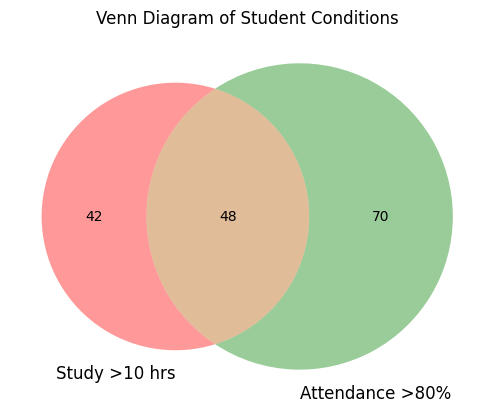

In [ ]:
# ---------------------------------------------------
#  VENN DIAGRAM VISUALIZATION
# ---------------------------------------------------

from matplotlib_venn import venn2

plt.figure()
venn2(subsets=(only_study, only_attendance, both_count),
      set_labels=('Study >10 hrs', 'Attendance >80%'))

plt.title("Venn Diagram of Student Conditions")
plt.show()

## 5. Contingency Table & Probability Calculaions

In [15]:
# -----------------------------------------
# 5. CONTINGENCY TABLE
# -----------------------------------------

print("\nContingency Table (Group Discussion vs Final Exam Result):")

cont_table = pd.crosstab(df['group_discussion'], df['final_exam_pass'])
display(cont_table)

# Total students
total = len(df)

# Values from table
gd_pass = cont_table.loc['Yes','Pass']
gd_fail = cont_table.loc['Yes','Fail']
no_pass = cont_table.loc['No','Pass']
no_fail = cont_table.loc['No','Fail']

# -----------------------------------------
# JOINT PROBABILITY
# Participates in group discussion AND Pass
# -----------------------------------------

joint_prob = gd_pass / total

print("\nJoint Probability (Group Discussion AND Pass):")
print(round(joint_prob,4))

# -----------------------------------------
# MARGINAL PROBABILITY
# Pass exam
# -----------------------------------------

total_pass = df[df['final_exam_pass'] == 'Pass'].shape[0]

marginal_prob = total_pass / total

print("\nMarginal Probability (Pass Exam):")
print(round(marginal_prob,4))

# -----------------------------------------
# CONDITIONAL PROBABILITY
# Pass given Group Discussion
# -----------------------------------------

total_gd = df[df['group_discussion'] == 'Yes'].shape[0]

conditional_prob = gd_pass / total_gd

print("\nConditional Probability (Pass | Group Discussion):")
print(round(conditional_prob,4))



Contingency Table (Group Discussion vs Final Exam Result):


final_exam_pass,Fail,Pass
group_discussion,,
No,34,66
Yes,9,91



Joint Probability (Group Discussion AND Pass):
0.455

Marginal Probability (Pass Exam):
0.785

Conditional Probability (Pass | Group Discussion):
0.91


## 6. Understanding Relationships

In [ ]:

# -----------------------------------------
# 6. UNDERSTANDING RELATIONSHIPS
# -----------------------------------------

print("\nINTERPRETATION:")

print("""
Conditional probability tells us the chance of passing the exam when we already know that a student participated in group discussion.

If this probability is higher than the overall pass probability,then group discussion may help students perform better.""")

# Independence check

P_A = total_gd / total
P_B = total_pass / total
P_A_and_B = joint_prob

print("\nCheck Independence:")

print("P(A) =", round(P_A,4))
print("P(B) =", round(P_B,4))
print("P(A AND B) =", round(P_A_and_B,4))
print("P(A)*P(B) =", round(P_A * P_B,4))

if round(P_A_and_B,4) == round(P_A * P_B,4):
    print("\nEvents are Independent")
else:
    print("\nEvents are Dependent")

print("""
They are NOT mutually exclusive because a student can BOTH 
participate in group discussion AND pass the exam.
""")


INTERPRETATION:

Conditional probability tells us the chance of passing the exam 
when we already know that a student participated in group discussion.

If this probability is higher than the overall pass probability,
then group discussion may help students perform better.


Check Independence:
P(A) = 0.5
P(B) = 0.785
P(A AND B) = 0.455
P(A)*P(B) = 0.3925

Events are Dependent

They are NOT mutually exclusive because a student can BOTH 
participate in group discussion AND pass the exam.



## 7. Bayes' Theorem Application

In [17]:
# -----------------------------------------
# 7. BAYES THEOREM APPLICATION
# -----------------------------------------

print("\nBAYES THEOREM CALCULATION")

# Given probabilities
P_pass_given_high_att = 0.70
P_fail_given_high_att = 0.40
P_high_att = 0.60

# P(Pass)
P_pass = marginal_prob

# Bayes formula
# P(Pass | High Attendance)

bayes_result = (P_pass_given_high_att * P_high_att) / P_pass

print("\nProbability student PASSED given HIGH attendance:")
print(round(bayes_result,4))


BAYES THEOREM CALCULATION

Probability student PASSED given HIGH attendance:
0.535
